In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
dataDir = "dataset_small"
imgSize = 120
validExt = (".jpg", ".jpeg", ".png")


def loadImagesFromFolder(folder, label):
    """Load and resize all valid images from a class folder, paired with their label."""
    images, labels = [], []
    folderPath = os.path.join(dataDir, folder)

    for fname in os.listdir(folderPath):
        if not fname.lower().endswith(validExt):
            continue
        imgPath = os.path.join(folderPath, fname)
        try:
            img = Image.open(imgPath).convert("RGB").resize((imgSize, imgSize))
            images.append(np.array(img))
            labels.append(label)
        except Exception as e:
            print(f"Skipping {fname}: {e}")

    return images, labels


posImages, posLabels = loadImagesFromFolder("Positive", 1)
negImages, negLabels = loadImagesFromFolder("Negative", 0)

X = np.array(posImages + negImages, dtype="float32") / 255.0
y = np.array(posLabels + negLabels, dtype="int32")

print(f"Loaded {len(X)} images -> shape {X.shape}, labels {y.shape}")

Loaded 120 images -> shape (120, 120, 120, 3), labels (120,)


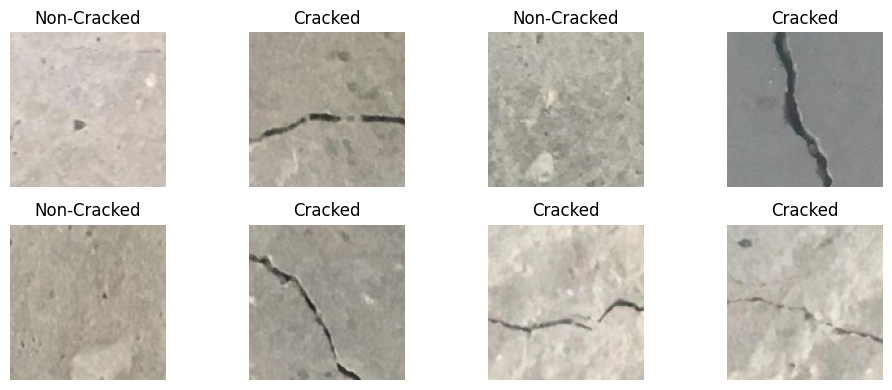

In [5]:
classNames = ["Non-Cracked", "Cracked"]

plt.figure(figsize=(10, 4))
idxs = np.random.choice(len(X), 8, replace=False)
for i, idx in enumerate(idxs):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X[idx])
    plt.title(classNames[y[idx]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [6]:
xTrain, xTemp, yTrain, yTemp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
xVal, xTest, yVal, yTest = train_test_split(
    xTemp, yTemp, test_size=0.50, random_state=42, stratify=yTemp
)

print(f"train {xTrain.shape}, val {xVal.shape}, test {xTest.shape}")

train (84, 120, 120, 3), val (18, 120, 120, 3), test (18, 120, 120, 3)


In [7]:
dataAugmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [8]:
model = models.Sequential([
    layers.Input(shape=(imgSize, imgSize, 3)),
    dataAugmentation,

    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 120, 120, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 60, 60, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       460,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 475,265 (1.81 MB)

 Trainable params: 475,265 (1.81 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
epochs = 25

earlyStop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = model.fit(
    xTrain, yTrain,
    validation_data=(xVal, yVal),
    epochs=epochs,
    batch_size=16,
    callbacks=[earlyStop]
)

Epoch 1/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 20s 436ms/step - accuracy: 0.4881 - loss: 0.7156 - val_accuracy: 0.5000 - val_loss: 0.6881
Epoch 2/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 219ms/step - accuracy: 0.5476 - loss: 0.7330 - val_accuracy: 0.5000 - val_loss: 0.6863
Epoch 3/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 213ms/step - accuracy: 0.5000 - loss: 0.6908 - val_accuracy: 0.5000 - val_loss: 0.6899
Epoch 4/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step - accuracy: 0.5000 - loss: 0.6827 - val_accuracy: 0.5000 - val_loss: 0.6895
Epoch 5/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accuracy: 0.5119 - loss: 0.6917 - val_accuracy: 0.5000 - val_loss: 0.6886
Epoch 6/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 228ms/step - accuracy: 0.5000 - loss: 0.6770 - val_accuracy: 0.5000 - val_loss: 0.6896
Epoch 7/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step - accuracy: 0.5119 - loss: 0.6832 - val_accuracy: 0.5000 - val_loss: 0.6733
Epoch 8/25
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 214ms/step - accuracy: 0.5714 - loss: 0.6754 - val_accuracy: 0.7778 - val_loss

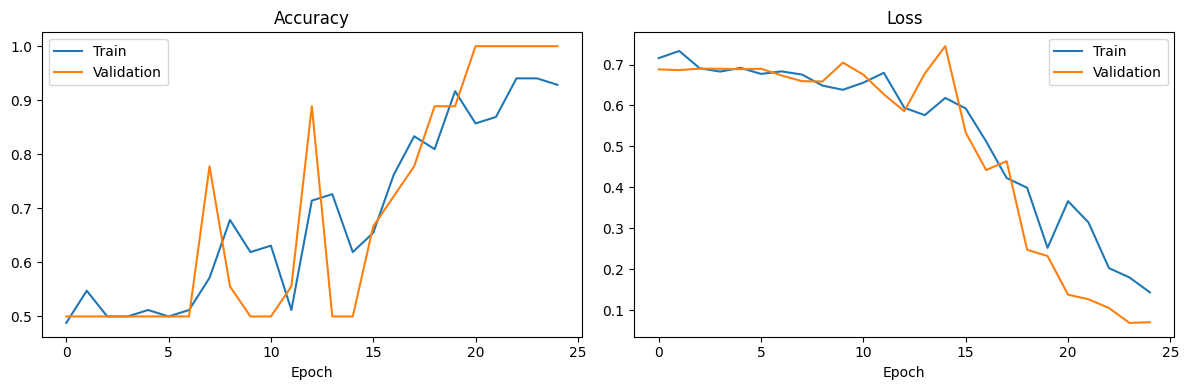

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
testLoss, testAcc = model.evaluate(xTest, yTest)
print(f"test accuracy {testAcc:.3f}, test loss {testLoss:.3f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 1.0000 - loss: 0.0679
test accuracy 1.000, test loss 0.068


In [12]:
from sklearn.metrics import classification_report, confusion_matrix

yPredProb = model.predict(xTest)
yPred = (yPredProb > 0.5).astype(int).flatten()

print(classification_report(yTest, yPred, target_names=classNames))
print("confusion matrix")
print(confusion_matrix(yTest, yPred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
              precision    recall  f1-score   support

 Non-Cracked       1.00      1.00      1.00         9
     Cracked       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

confusion matrix
[[9 0]
 [0 9]]


In [14]:
encoderInput = layers.Input(shape=(imgSize, imgSize, 3))

x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(encoderInput)
x = layers.MaxPooling2D(padding="same")(x)
x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D(padding="same")(x)

x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D()(x)
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D()(x)
decoded = layers.Conv2D(3, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = models.Model(encoderInput, decoded)
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 120, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 120, 120, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 60, 60, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 60, 60, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 30, 30, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 60, 60, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 120, 120, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 120, 120, 3)    │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,795 (14.82 KB)

 Trainable params: 3,795 (14.82 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
autoencoder.fit(
    xTrain, xTrain,
    validation_data=(xVal, xVal),
    epochs=30,
    batch_size=16,
    verbose=1
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 386ms/step - loss: 0.0377 - val_loss: 0.0231
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 160ms/step - loss: 0.0205 - val_loss: 0.0088
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - loss: 0.0134 - val_loss: 0.0091
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.0127 - val_loss: 0.0081
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step - loss: 0.0121 - val_loss: 0.0074
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - loss: 0.0115 - val_loss: 0.0075
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.0116 - val_loss: 0.0071
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 237ms/step - loss: 0.0113 - val_loss: 0.0070
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - loss: 0.0110 - val_loss: 0.0069
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - loss: 0.0108 - val_loss: 0.0068
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - loss: 0.0106 - val_loss: 0.0066
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - loss: 0.0106 - val_lo

In [16]:
reconVal = autoencoder.predict(xVal)
errorsVal = np.mean(np.square(xVal - reconVal), axis=(1, 2, 3))

threshold = np.mean(errorsVal) + 2 * np.std(errorsVal)
print(f"mean error {np.mean(errorsVal):.5f}, std {np.std(errorsVal):.5f}")
print(f"anomaly threshold {threshold:.5f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 732ms/step
mean error 0.00188, std 0.00081
anomaly threshold 0.00351


In [17]:
autoencoder.save("anomalyDetector.keras")

with open("anomalyThreshold.txt", "w") as f:
    f.write(str(threshold))

In [13]:
model.save("crackDetectionModel.keras")